# churn behaviour per meaningful segment? and proposed strategy

1. overall analysis
2. clustering
3. cluster investigation and sementation
4. definitions of meaningful segments
5. proposed strategy for segments
6. conclusion

In [1]:
import pandas as pd
original_df = pd.read_csv('../dataset/cleaned_churn_data.csv')
encoded_df = pd.read_csv('../dataset/cleaned_encoded_churn_data.csv')

## overall analysis

In [2]:
original_df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [3]:
# check data split on churn

data_split_df = pd.DataFrame(original_df['Churn'].value_counts())
data_split_df['Percentage'] = data_split_df['count'] / data_split_df['count'].sum() * 100
data_split_df

,count,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


# clustering

kmeans vs kprototypes:
- kmeans more mature, but has innate weakness of measuring euclidean distance of hot-one encoding
- kprototypes theoretically better for mixed datatype, but hard to visualise

### kmeans

In [4]:
import matplotlib.pyplot as plt
import logging

plt.style.use("ggplot")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

Text(0.5, 1.0, 'Scree Plot')

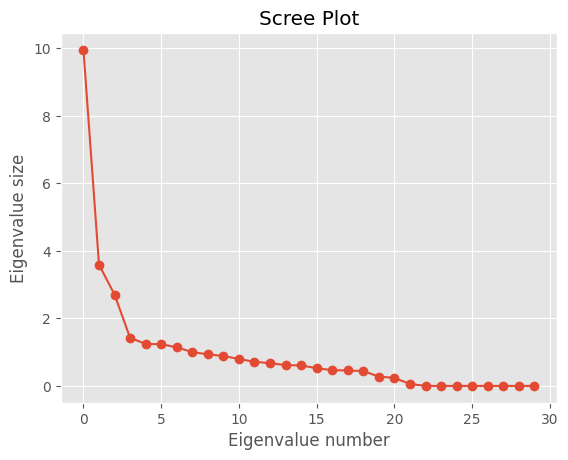

In [5]:
# deciding on number of PCA dimensions to keep

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_columns = [col for col in encoded_df.columns if col != 'customerID' and col != 'Churn']
X = encoded_df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=len(feature_columns))
X_pca = pca.fit_transform(X_scaled)

plt.style.use("ggplot") 
plt.plot(pca.explained_variance_, marker='o')
plt.xlabel("Eigenvalue number")
plt.ylabel("Eigenvalue size")
plt.title("Scree Plot")

In [6]:
# clustering into 1) low risk, 2) high risk

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

feature_columns = [col for col in encoded_df.columns if col != 'customerID' and col != 'Churn']
X = encoded_df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

k_means_2 = KMeans(n_clusters=2, random_state=42)
clusters_2 = k_means_2.fit_predict(X_pca)
clusters_2_df = original_df.copy()
clusters_2_df['Cluster'] = clusters_2

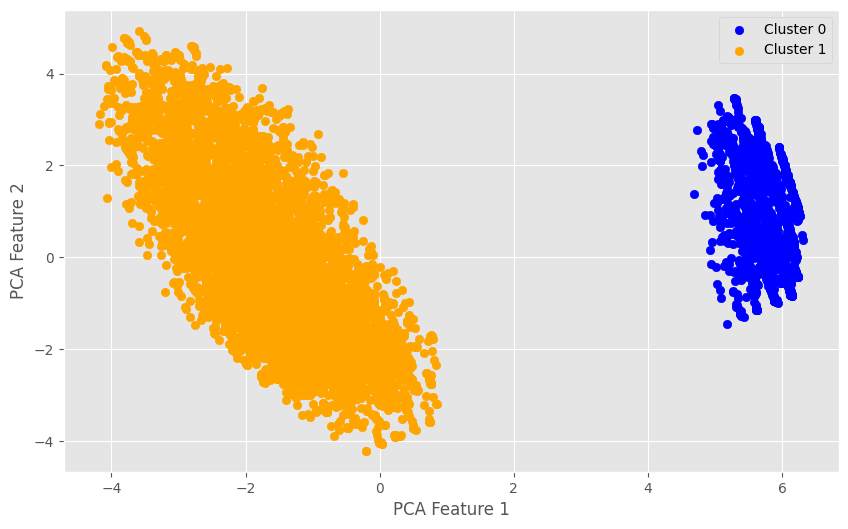

In [7]:
import numpy as np

cluster_colors = {0: 'blue', 1: 'orange'}
plt.figure(figsize=(10, 6))

for cluster_id, color in cluster_colors.items():
     cluster_mask = np.where(clusters_2== cluster_id)
     plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], c=color, label=f'Cluster {cluster_id}')


plt.legend()
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.show()

clusters_2_df['PCA_1'] = X_pca[:, 0]
clusters_2_df['PCA_2'] = X_pca[:, 1]

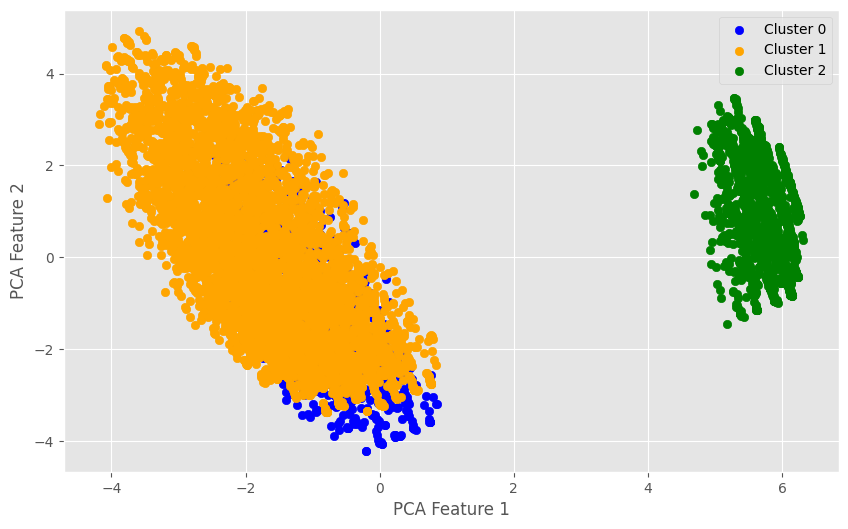

In [8]:
# clustering into 1) low risk, 2) high risk, 3) medium risk

import matplotlib.pyplot as plt

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

k_means_3 = KMeans(n_clusters=3, random_state=42)
clusters_3 = k_means_3.fit_predict(X_pca)
clusters_3_df = original_df.copy()
clusters_3_df['Cluster'] = clusters_3

cluster_colors = {0: 'blue', 1: 'orange', 2: 'green'}
plt.figure(figsize=(10, 6))

for cluster_id, color in cluster_colors.items():
     cluster_mask = np.where(clusters_3== cluster_id)
     plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], c=color, label=f'Cluster {cluster_id}')


plt.legend()
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.show()

clusters_3_df['PCA_1'] = X_pca[:, 0]
clusters_3_df['PCA_2'] = X_pca[:, 1]

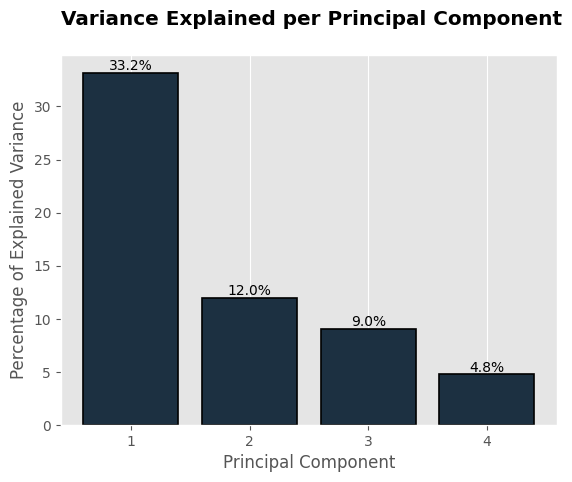

In [9]:
# visualising pca explained variance

plot_y = [val * 100 for val in pca.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

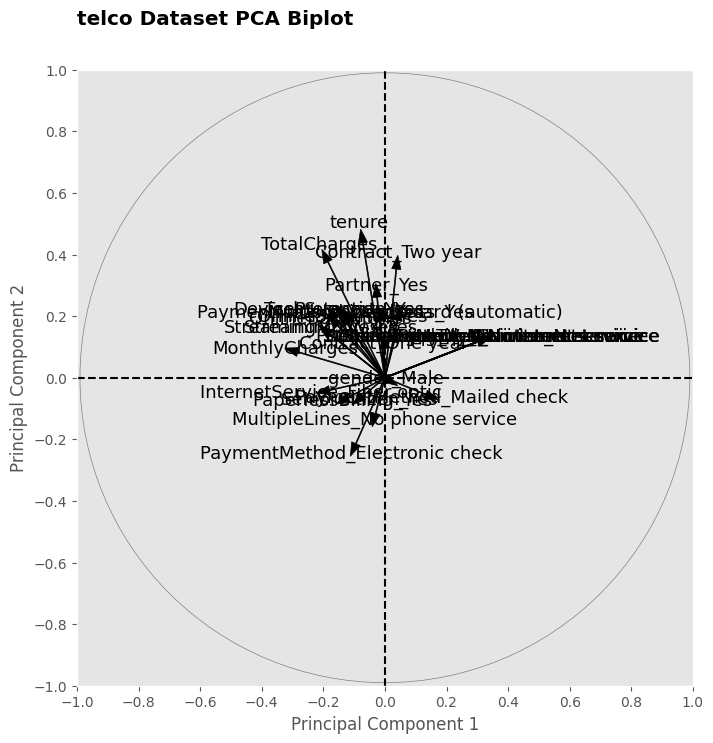

In [10]:
# biplot

labels = X.columns
n = len(labels)
coeff = np.transpose(pca.components_)
pc1 = pca.components_[:, 0]
pc2 = pca.components_[:, 1]

plt.figure(figsize=(8, 8))

for i in range(n):
    plt.arrow(x=0, y=0, dx=coeff[i, 0], dy=coeff[i, 1], color="#000000", width=0.003, head_width=0.03)
    plt.text(x=coeff[i, 0] * 1.15, y=coeff[i, 1] * 1.15, s=labels[i], size=13, color="#000000", ha="center", va="center")

plt.axis("square")
plt.title(f"telco Dataset PCA Biplot", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.yticks(np.arange(-1, 1.1, 0.2))

plt.axhline(y=0, color="black", linestyle="--")
plt.axvline(x=0, color="black", linestyle="--")
circle = plt.Circle((0, 0), 0.99, color="gray", fill=False)
plt.gca().add_artist(circle)

plt.grid()
plt.show()

In [11]:
clusters_2_churn_df = pd.DataFrame(clusters_2_df.groupby('Cluster')['Churn'].value_counts(normalize=False))
clusters_3_churn_df = pd.DataFrame(clusters_3_df.groupby('Cluster')['Churn'].value_counts(normalize=False))

yes_num = original_df[original_df['Churn'] == 'Yes'].shape[0]
no_num = original_df[original_df['Churn'] == 'No'].shape[0]

clusters_2_churn_norm_df = pd.DataFrame(clusters_2_df.groupby('Cluster')['Churn'].value_counts(normalize=True))
clusters_3_churn_norm_df = pd.DataFrame(clusters_3_df.groupby('Cluster')['Churn'].value_counts(normalize=True))

for row_norm, row in zip(clusters_2_churn_norm_df.itertuples(), clusters_2_churn_df.itertuples()):
    cluster_id = row.Index[0]
    churn_status = row.Index[1]
    count = row.count
    percentage = (count / yes_num * 100) if churn_status == 'Yes' else (count / no_num * 100)
    clusters_2_churn_norm_df.at[(cluster_id, churn_status), f'Percentage_{churn_status}'] = percentage

for row_norm, row in zip(clusters_3_churn_norm_df.itertuples(), clusters_3_churn_df.itertuples()):
    cluster_id = row.Index[0]
    churn_status = row.Index[1]
    count = row.count
    percentage = (count / yes_num * 100) if churn_status == 'Yes' else (count / no_num * 100)
    clusters_3_churn_norm_df.at[(cluster_id, churn_status), f'Percentage_{churn_status}'] = percentage

cluster_0_num_clusters_2 = clusters_2_df[clusters_2_df['Cluster'] == 0].shape[0]/clusters_2_df.shape[0] * 100
cluster_1_num_clusters_2 = clusters_2_df[clusters_2_df['Cluster'] == 1].shape[0]/clusters_2_df.shape[0] * 100

cluster_0_num_clusters_3 = clusters_3_df[clusters_3_df['Cluster'] == 0].shape[0]/clusters_3_df.shape[0] * 100
cluster_1_num_clusters_3 = clusters_3_df[clusters_3_df['Cluster'] == 1].shape[0]/clusters_3_df.shape[0] * 100
cluster_2_num_clusters_3 = clusters_3_df[clusters_3_df['Cluster'] == 2].shape[0]/clusters_3_df.shape[0] * 100

cluster_distribution_clusters_2_df = pd.DataFrame({'0':cluster_0_num_clusters_2, '1':cluster_1_num_clusters_2}, index=['Cluster Distribution'])
cluster_distribution_clusters_3_df = pd.DataFrame({'0':cluster_0_num_clusters_3, '1':cluster_1_num_clusters_3, '2':cluster_2_num_clusters_3}, index=['Cluster Distribution'])

display(cluster_distribution_clusters_2_df)
display(cluster_distribution_clusters_3_df)

display(clusters_2_churn_norm_df)
display(clusters_3_churn_norm_df)


''' 

cluster 0 of k = 2 == cluster 2 of k = 3

(k = 2) 
- both clusters have mostly non-churn
- cluster 1 has most of the churned customers
- cluster 0 can be considered as low risk, cluster 1 can be considered as high risk

(k = 3)
- cluster 2 can be considered as low risk, cluster 0 and 1 can be considered as high risk
- what is the difference between cluster 0 and 1?: cluster 0 has more churned customers than cluster 1, but cluster 1 has more customers than cluster 0. cluster 0 can be considered as very high risk, cluster 1 can be considered as medium risk.

'''

,0,1
Cluster Distribution,21.666903,78.333097


,0,1,2
Cluster Distribution,9.683374,68.649723,21.666903


proportion  Percentage_No  Percentage_Yes
Cluster Churn                                           
0       No       0.925950      27.309625             NaN
        Yes      0.074050            NaN        6.046014
1       No       0.681711      72.690375             NaN
        Yes      0.318289            NaN       93.953986

proportion  Percentage_No  Percentage_Yes
Cluster Churn                                           
0       No       0.750733       9.895632             NaN
        Yes      0.249267            NaN        9.095773
1       No       0.671975      62.794743             NaN
        Yes      0.328025            NaN       84.858213
2       No       0.925950      27.309625             NaN
        Yes      0.074050            NaN        6.046014

' \n\ncluster 0 of k = 2 == cluster 2 of k = 3\n\n(k = 2) \n- both clusters have mostly non-churn\n- cluster 1 has most of the churned customers\n- cluster 0 can be considered as low risk, cluster 1 can be considered as high risk\n\n(k = 3)\n- cluster 2 can be considered as low risk, cluster 0 and 1 can be considered as high risk\n- what is the difference between cluster 0 and 1?: cluster 0 has more churned customers than cluster 1, but cluster 1 has more customers than cluster 0. cluster 0 can be considered as very high risk, cluster 1 can be considered as medium risk.\n\n'

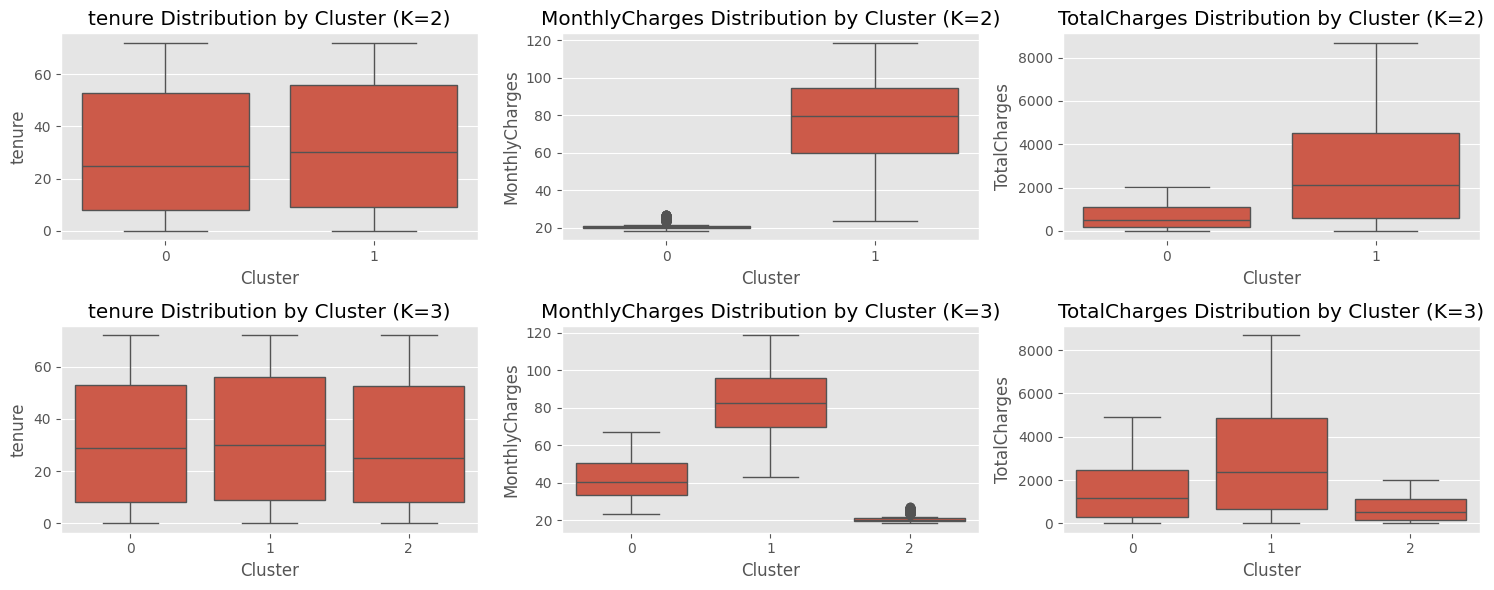

In [12]:
# investigate distribution of variables in each cluster

import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
variables_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col, var in enumerate(variables_to_analyze):
    sns.boxplot(x='Cluster', y=var, data=clusters_2_df, ax=axes[0, col])
    axes[0, col].set_title(f'{var} Distribution by Cluster (K=2)')

for col, var in enumerate(variables_to_analyze) :
    sns.boxplot(x='Cluster', y=var, data=clusters_3_df, ax=axes[1, col])
    axes[1, col].set_title(f'{var} Distribution by Cluster (K=3)')

plt.tight_layout()
plt.show()

In [13]:
cat_cols = [col for col in feature_columns if col != 'tenure' and col !='MonthlyCharges' and col != 'TotalCharges']
original_cat_cols = [col for col in original_df.columns.to_list() if col != 'tenure' and col !='MonthlyCharges' and col != 'TotalCharges' and col != 'customerID' and col != 'Churn']

col_df_dict_2 = {}
col_df_dict_3 = {}

for col in original_cat_cols:
    col_df_dict_2[f"{col}_df"] = clusters_2_df.groupby(['Cluster'])[col].value_counts(normalize=True).unstack()
    col_df_dict_3[f"{col}_df"] = clusters_3_df.groupby(['Cluster'])[col].value_counts(normalize=True).unstack()
    
len(col_df_dict_2.keys())

16

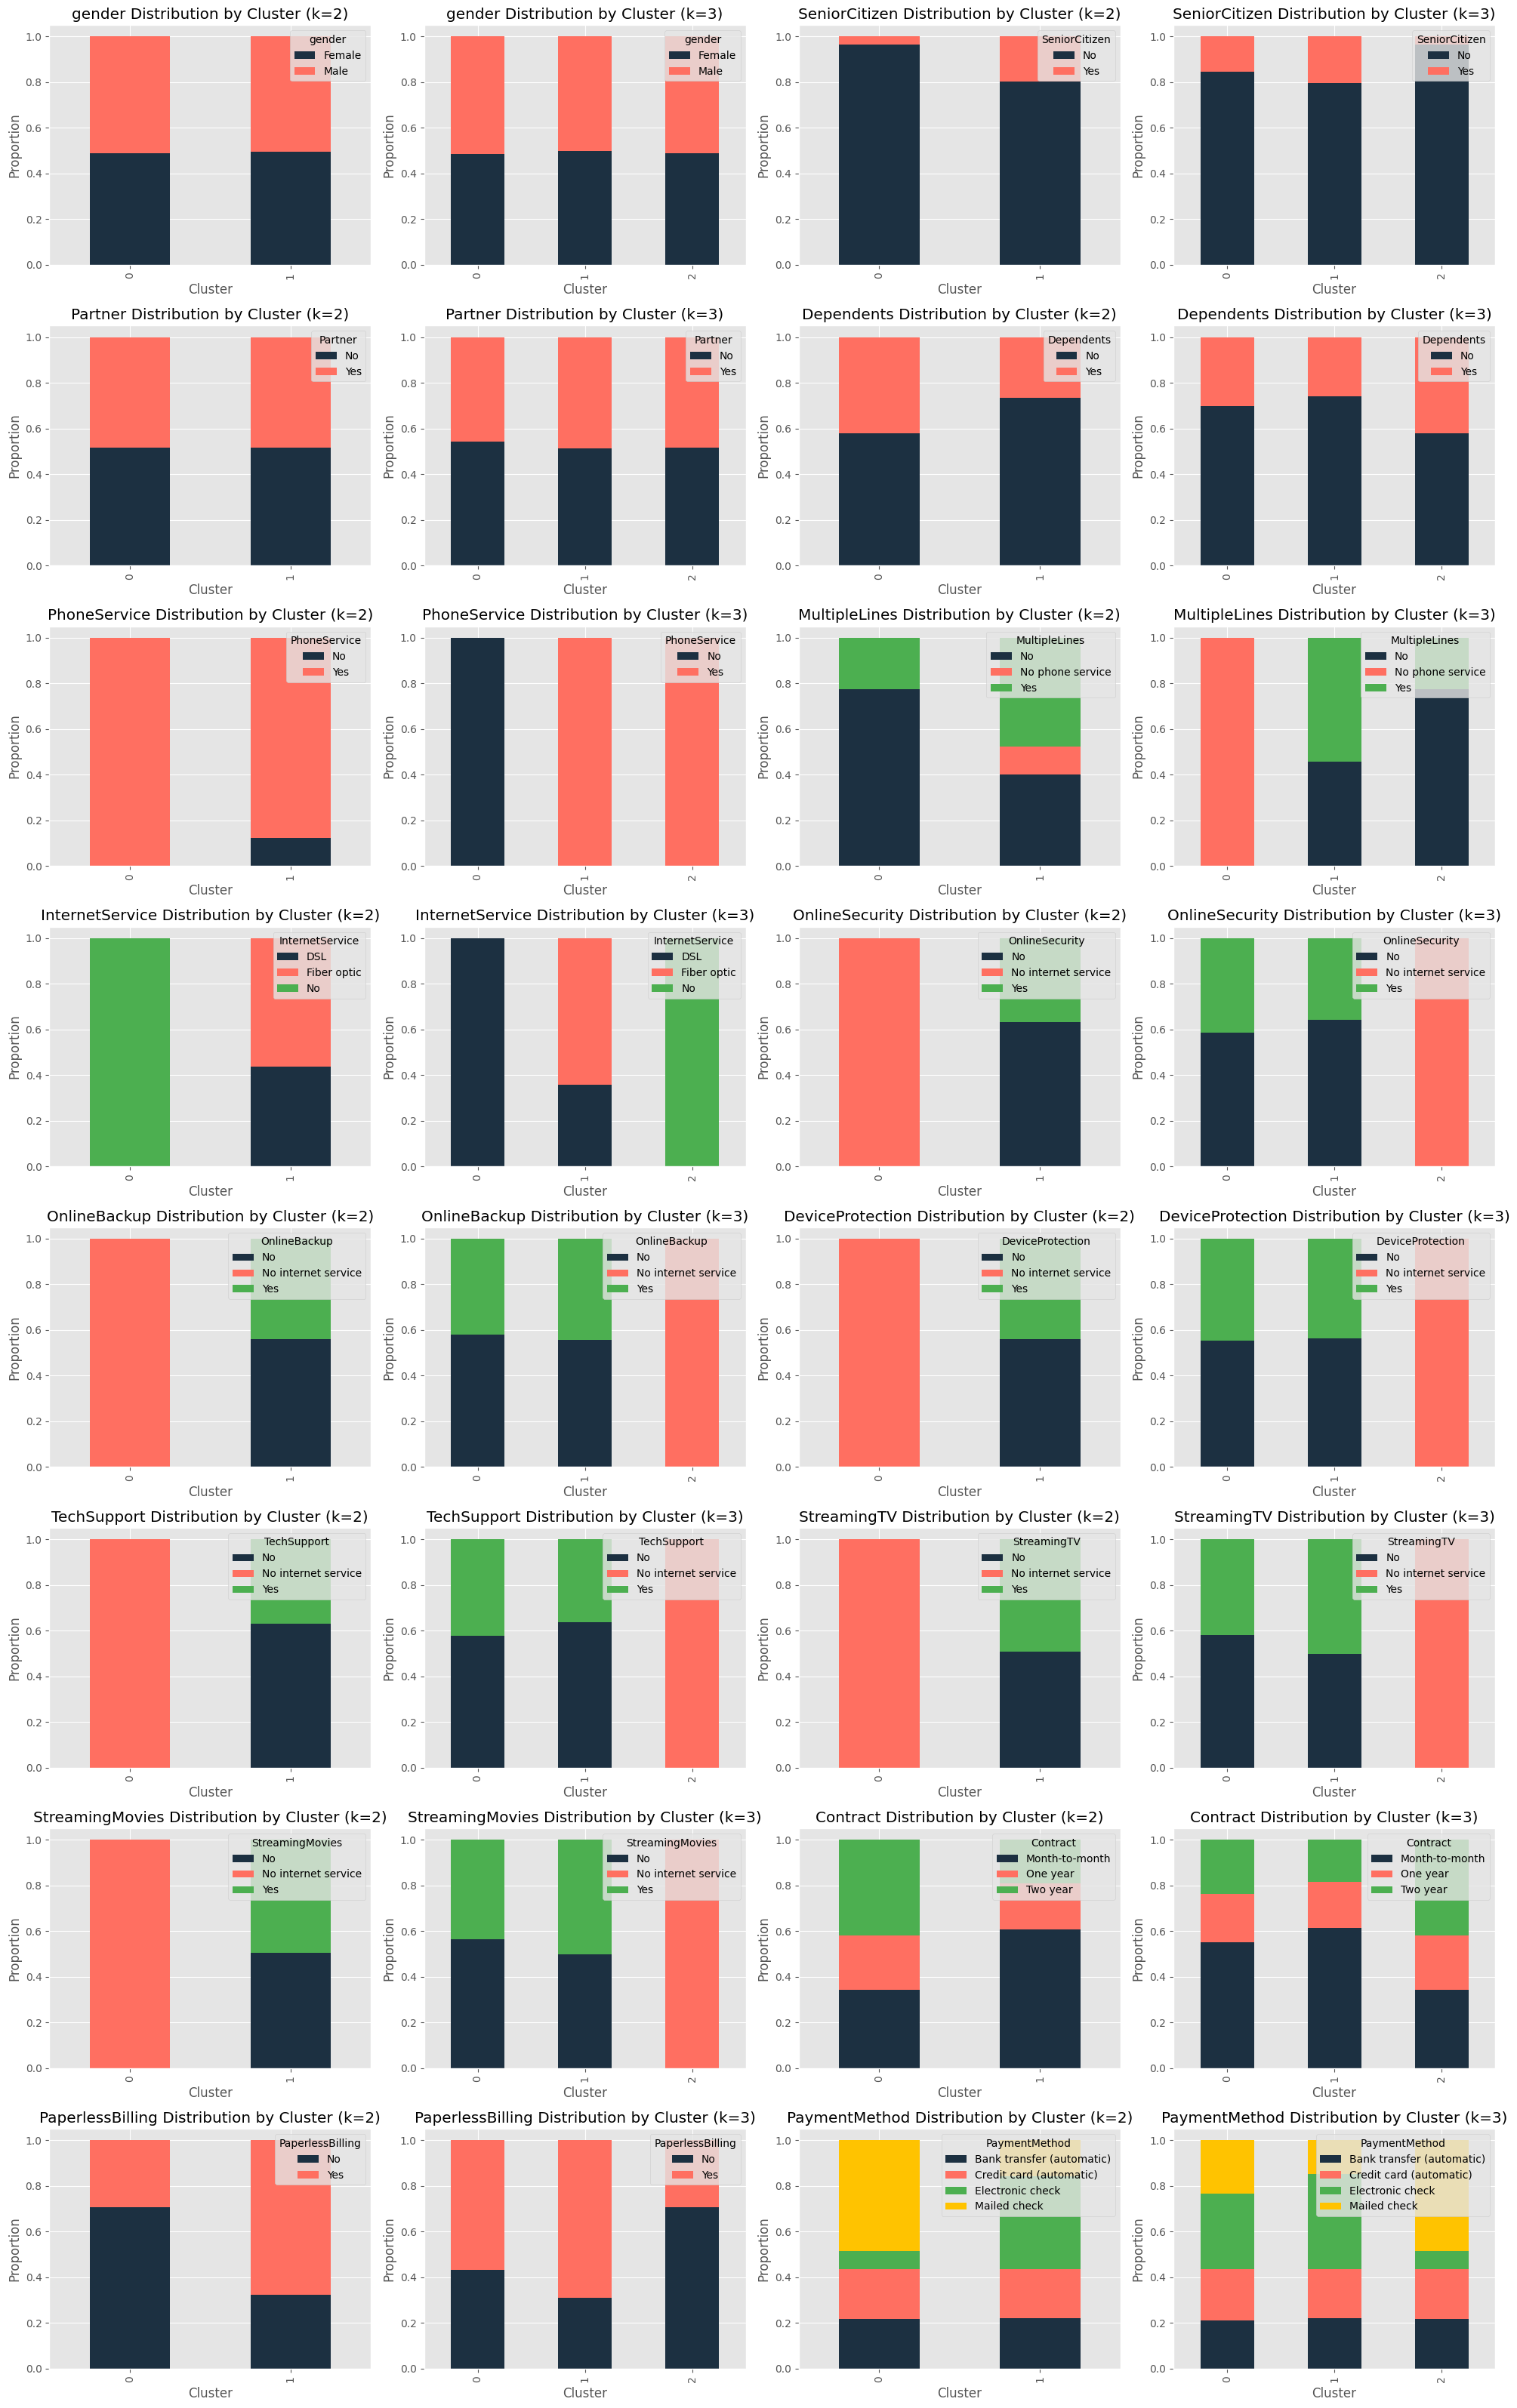

In [14]:
fig, axes = plt.subplots(8, 4, figsize=(20, 32))
row, col = 0,0

for (col_name_2, col_df_2), (col_name_3, col_df_3) in zip(col_df_dict_2.items(), col_df_dict_3.items()):
    col_df_2.plot(kind='bar', stacked=True, ax=axes[row, col], color=['#1C3041', '#FF6F61', '#4CAF50', '#FFC300', '#C70039'])
    axes[row, col].set_title(f'{col_name_2[:-3]} Distribution by Cluster (k=2)')
    axes[row, col].set_xlabel('Cluster')
    axes[row, col].set_ylabel('Proportion')
    axes[row, col].legend(title=col_name_2[:-3], loc='upper right')

    col += 1

    col_df_3.plot(kind='bar', stacked=True, ax=axes[row, col], color=['#1C3041', '#FF6F61', '#4CAF50', '#FFC300', '#C70039'])
    axes[row, col].set_title(f'{col_name_3[:-3]} Distribution by Cluster (k=3)')
    axes[row, col].set_xlabel('Cluster')
    axes[row, col].set_ylabel('Proportion')
    axes[row, col].legend(title=col_name_2[:-3], loc='upper right')

    col += 1
    
    if col == 4:
        col = 0
        row += 1

plt.subplots_adjust(hspace=0.5, wspace=0.8)
plt.tight_layout()
plt.show()

### kmeans observations
2 clusters:
- significant factors in differentiating between low and high risk churn are monthlycharge and totalcharge (low overlap), phone service, internet service, paperless billing and payment method
- less likely to churn: dependents, phone service, no internet service, 2-year contract, mailed check
- more likely to churn: senior citizens, optic fibre/dsl, month-to-month, paperless billing, electronic check

3 clusters:
- significant factors in differentiating between low and high risk churn are monthlycharge and totalcharge (low overlap), phone service, internet service, paperless billing and payment method
- significant factors in differentiating between medium and high risk churn are phone service (no = high), internet distribution (dsl = high, optic = medium, no = low)
- more likely to be low and high risk for senior citizen (not so much medium)
- less likely to churn: dependents, phone service, no internet service, 2-year contract, mailed check
- more likely to churn: senior citizens, optic fibre/dsl, month-to-month, paperless billing, electronic check

to be continued:
- investigate monthlycharge, totalcharge, phoneservice, internetservice, paperless billing, payment method

### kprototypes

In [15]:
from plotnine import *
import plotnine
from kmodes.kprototypes import KPrototypes
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [ ]:
new_df = original_df.drop(columns=['customerID', 'Churn'])
catColumnsPos = [new_df.columns.get_loc(col) for col in list(new_df.select_dtypes('object').columns)]
print('Categorical columns: {}'.format(list(new_df.select_dtypes('object').columns)))
print('Categorical columns position: {}'.format(catColumnsPos))

Categorical columns           : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Categorical columns position  : [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [17]:
# normalising scalar variables for clustering

X = new_df[new_df.select_dtypes(include=['int64', 'float64']).columns.to_list()]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
new_df[new_df.select_dtypes(include=['int64', 'float64']).columns.to_list()] = X_scaled

In [18]:
df_matrix = new_df.to_numpy()

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9


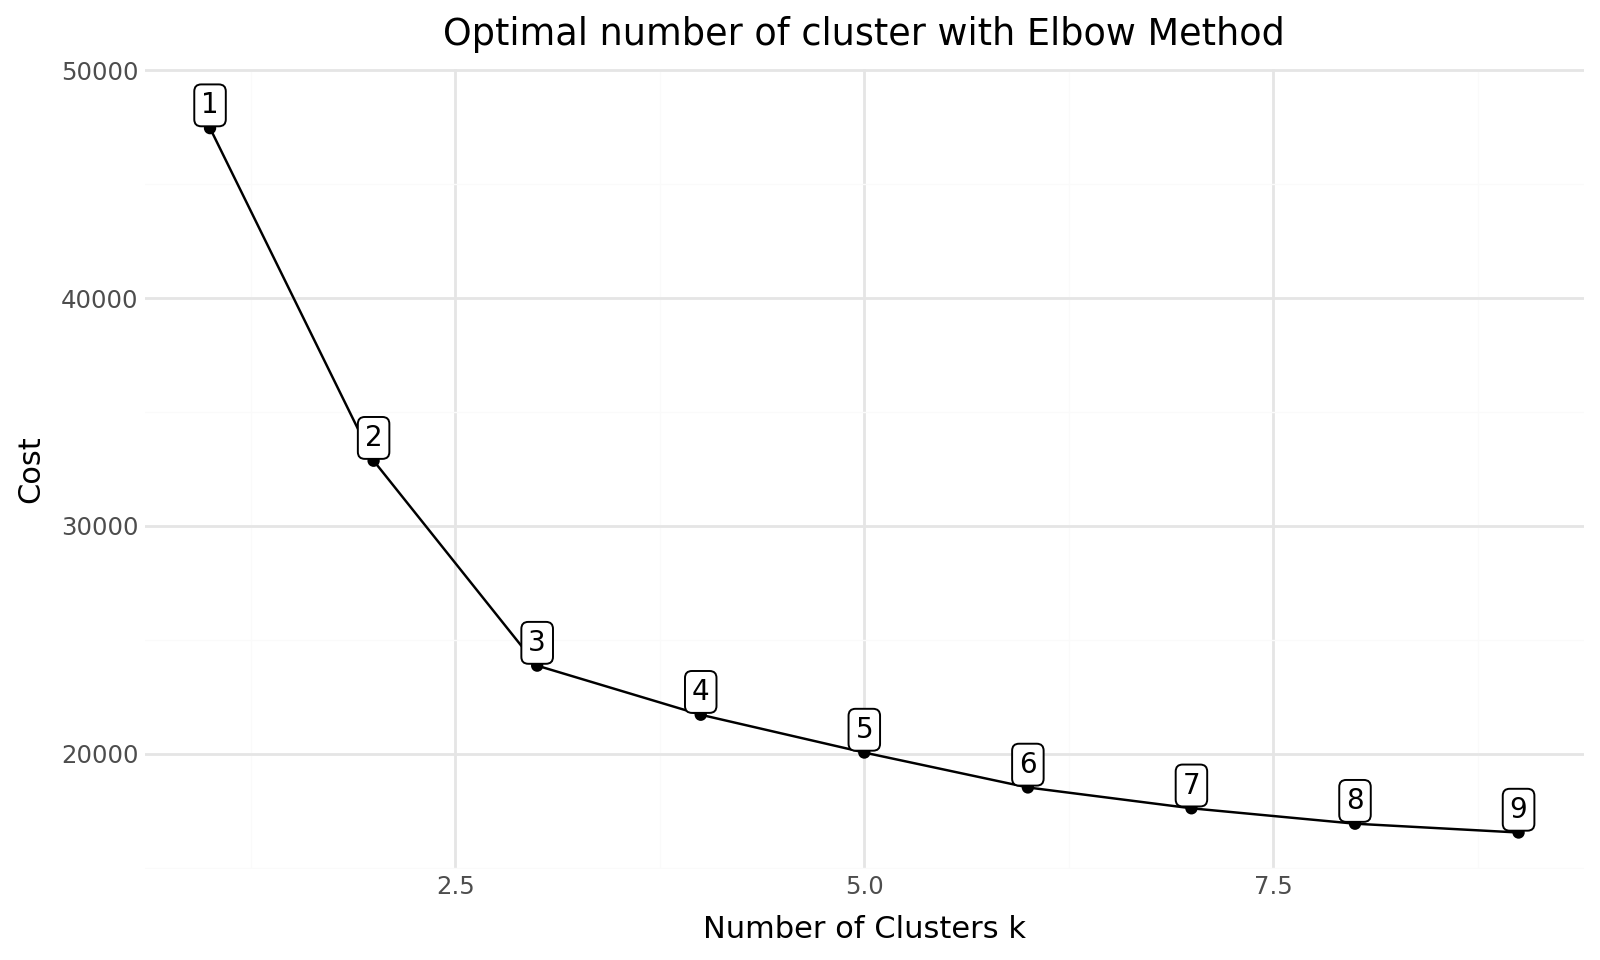

In [19]:
# optimal k using Elbow method
cost = []
for cluster in range(1, 10):
    try:
        kprototype = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype.fit_predict(df_matrix, categorical = catColumnsPos)
        cost.append(kprototype.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break

df_cost = pd.DataFrame({'Cluster': range(1, len(cost) + 1), 'Cost': cost})

plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [20]:
kprototype = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype.fit_predict(df_matrix, categorical = catColumnsPos)

new_df['Cluster'] = kprototype.labels_
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cluster
0,Female,No,Yes,No,-1.277445,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,-1.160323,-0.992611,0
1,Male,No,No,No,0.066327,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,-0.259629,-0.172165,0
2,Male,No,No,No,-1.236724,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,-0.362660,-0.958066,0
3,Male,No,No,No,0.514251,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),-0.746535,-0.193672,1
4,Female,No,No,No,-1.236724,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.197365,-0.938874,0


In [21]:
new_original_df = original_df.copy()
new_original_df['Cluster'] = kprototype.labels_
churn_rate = new_original_df.groupby('Cluster')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
churn_rate

Cluster
0    43.822630
1     7.259074
2    14.712644
Name: Churn, dtype: float64

In [22]:
# significant differentiating variables

significant_cat_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Contract', 'PaymentMethod']

def mode_with_pct(x):
    vc = x.value_counts(normalize=True)
    return f"{vc.index[0]} ({vc.iloc[0]:.0%})"

agg_dict = {
    col: mode_with_pct for col in significant_cat_cols
}
agg_dict.update({
    col: 'mean' for col in new_original_df.select_dtypes(include=['float64', 'int64']).columns
    if col != 'Cluster'
})

profiles = new_df.groupby('Cluster').agg(agg_dict)
profiles['Size'] = new_df.groupby('Cluster').size()
profiles = profiles.reset_index()

profiles

,Cluster,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Contract,PaymentMethod,tenure,MonthlyCharges,TotalCharges,Size
0,0,No (80%),No (66%),No (79%),Yes (86%),Yes (68%),Month-to-month (86%),Electronic check (50%),-0.687946,0.145102,-0.532283,3270
1,1,No (96%),No (52%),No (58%),Yes (95%),No (72%),Two year (42%),Mailed check (48%),-0.046252,-1.427073,-0.692485,1598
2,2,No (80%),Yes (70%),No (65%),Yes (93%),Yes (69%),Two year (44%),Bank transfer (automatic) (33%),1.068273,0.830334,1.309038,2175


### kprototypes observation
- 3 clusters is optimum, validates kmeans clustering
- cluster 0: highest churn, high risk
- cluster 1: lowest churn, low risk
- cluster 2: medium churn, medium risk

profiles of clusters:
- high risk: single, tech-savvy individuals with below average tenure and total charges, average monthly charges, low commitment contracts
- low risk: single, less tech-savvy middle aged demographic (no paperless billing + mailed check payment method), with average tenure, below average monthly charges and total charges, high commitment contracts
- medium risk: married tech-savvy individuals who opt for safer, yet convenient methods of payment with above average tenure, monthly charges and total charges

### segmentation:
- kprototypes profiles and kmeans profiles correlate with each other

- cluster 2: partnered, high-spend, long-tenured customers on two-year contracts with automatic bank-transfer payment. the low churn risk they suffer most likely comes from some mix of contract-driven lock-in, payment friction (autopay reduces the active decision to leave each month) and selection—customers with longer tenure are generally stable from the very beginning. 

- cluster 0: single and low-tenure customers, and on month-to-month contracts using paperless billing and electronic check payment. every feature provides low switching cost: no contractual lock-in, no payment friction, and little investment in the relationship. the highest churn risk lies with this category. 

- cluster 1 falls between the two: single customers on two-year contracts with minimal monthly spend but still traditional (mailed-check) payment. the length of the contract provides a buffer against churn, but the low spend indicates poor service engagement, likely phone-only or basic-service subscribers. risk is mild (contractually protected) for now but weak attachment beyond the contract term.

## proposed strategy
1. push for long-term contracts by offering great benefits for them (lowers risk immediately)
2. bundle additional services into existing customer plans to increase service depth and switching cost to increase monthly, total charges and tenure for individuals, to increase personal investment into the service (from kmeans, can be seen that these 3 features highly influence if an individual falls into the low or high risk cluster)
3. increase barrier to cancellation of plans such as high cancellation fees and a longer, more complicated process to doing so. however, high cancellation fees may deter those who are uncommitted in the first place which is the majority.
3. make automatic payment easier to set up
4. target the majority (uncommitted) by focusing on the first few months of tenure as these are the deciding months in which the individual decides to stay or not

## machine learning models

### random forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [24]:
df = original_df.copy()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

from sklearn.preprocessing import OrdinalEncoder
cat_cols = X.select_dtypes(include='object').columns.tolist()
X[cat_cols] = OrdinalEncoder().fit_transform(X[cat_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# predict

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7856635911994322


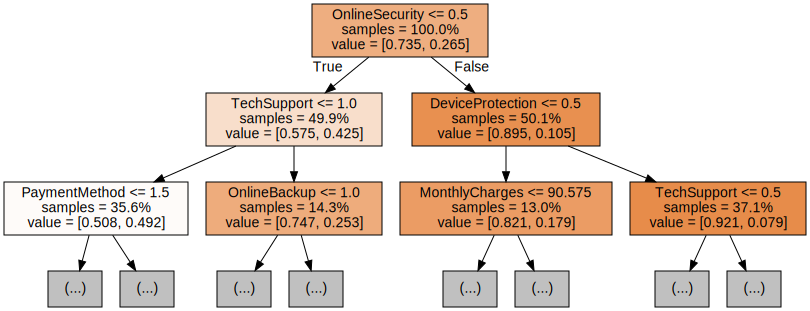

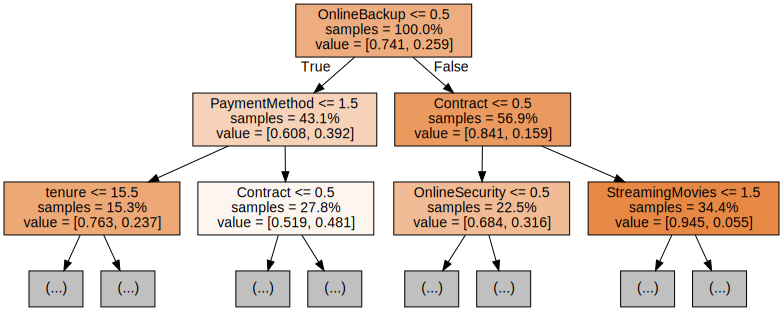

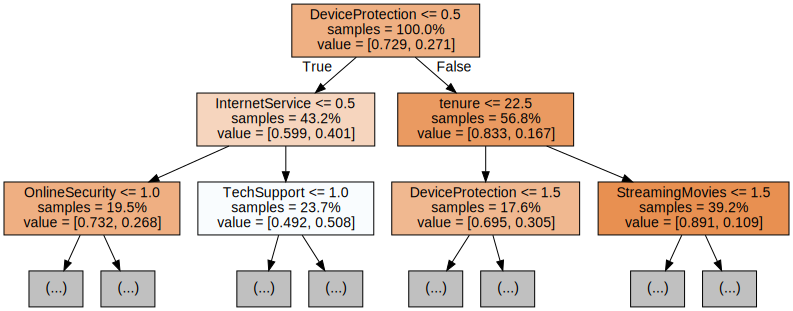

In [26]:
# export the first three decision trees from the forest

for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

In [27]:
param_dist = {
  'n_estimators': randint(100, 500),
  'max_depth': randint(3, 15),
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5)
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

rand_search = RandomizedSearchCV(
  rf, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='roc_auc',
  n_jobs=-1, random_state=42)

rand_search.fit(X_train, y_train) 

best_rf = rand_search.best_estimator_
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 444}


In [37]:
from sklearn.metrics import roc_auc_score, classification_report

best_rf = rand_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(f'Test AUC: {roc_auc_score(y_test, y_proba)}\n')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Accuracy: 0.7665010645848119
Test AUC: 0.842212405383761

              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



### gradient boosting (xgboost)

In [29]:
df = original_df.copy()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

from sklearn.preprocessing import OrdinalEncoder
cat_cols = X.select_dtypes(include='object').columns.tolist()
X[cat_cols] = OrdinalEncoder().fit_transform(X[cat_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1, random_state=27,
)

param_dist = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(3, 8),
    'min_child_weight': randint(1, 10),
    'gamma':            uniform(0, 0.4),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'learning_rate':    uniform(0.01, 0.2),
    'reg_alpha':        uniform(0, 1),
}

search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=50, cv=5, scoring='roc_auc',
    n_jobs=-1, random_state=42,
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV AUC:', search.best_score_)

Best params: {'colsample_bytree': 0.9404546686067428, 'gamma': 0.12676880206251107, 'learning_rate': 0.0438985493372185, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 157, 'reg_alpha': 0.9300168348108319, 'subsample': 0.6281664523398175}
Best CV AUC: 0.8482780385840047


Optimal trees: 149
Test AUC:      0.8477
Test accuracy: 0.7417

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



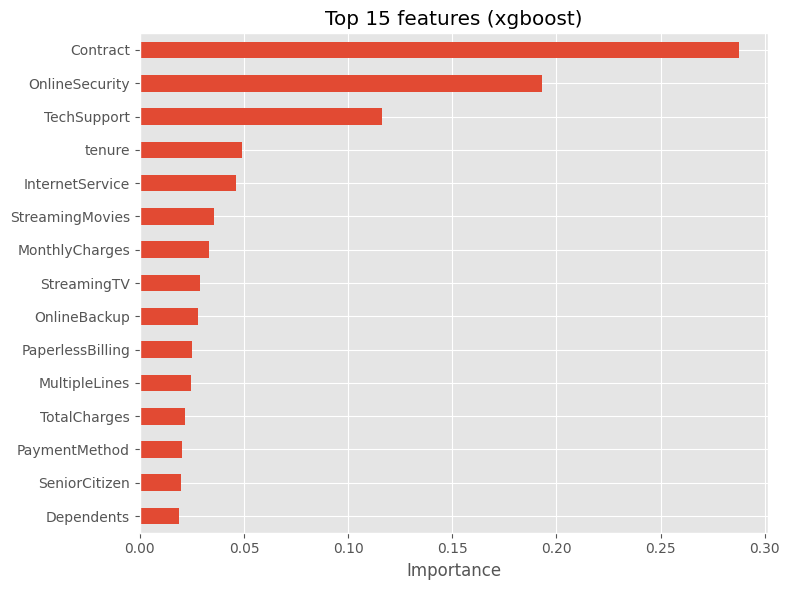

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

xgb_final = XGBClassifier(
    **search.best_params_,                                                           
    early_stopping_rounds=100,
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    n_jobs=-1, random_state=27,
)
xgb_final.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

y_pred  = xgb_final.predict(X_test)
y_proba = xgb_final.predict_proba(X_test)[:, 1]

print(f'Optimal trees: {xgb_final.best_iteration}')
print(f'Test AUC:      {roc_auc_score(y_test, y_proba):.4f}')
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Feature importance
importances = pd.Series(xgb_final.feature_importances_, index=X_train.columns).sort_values()
importances.tail(15).plot.barh(figsize=(8, 6))
plt.xlabel('Importance')
plt.title('Top 15 features (xgboost)')
plt.tight_layout()
plt.show()

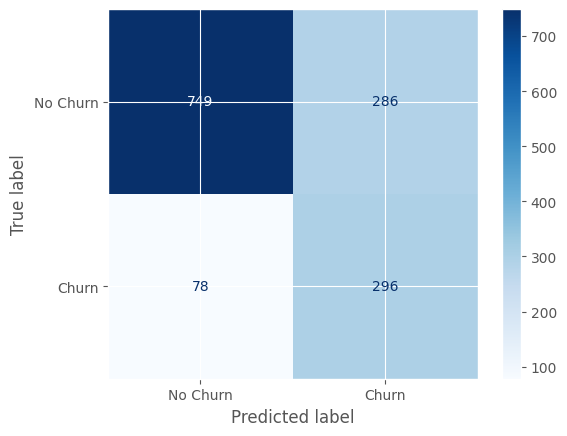

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Churn', 'Churn'], cmap='Blues'
)
plt.show()

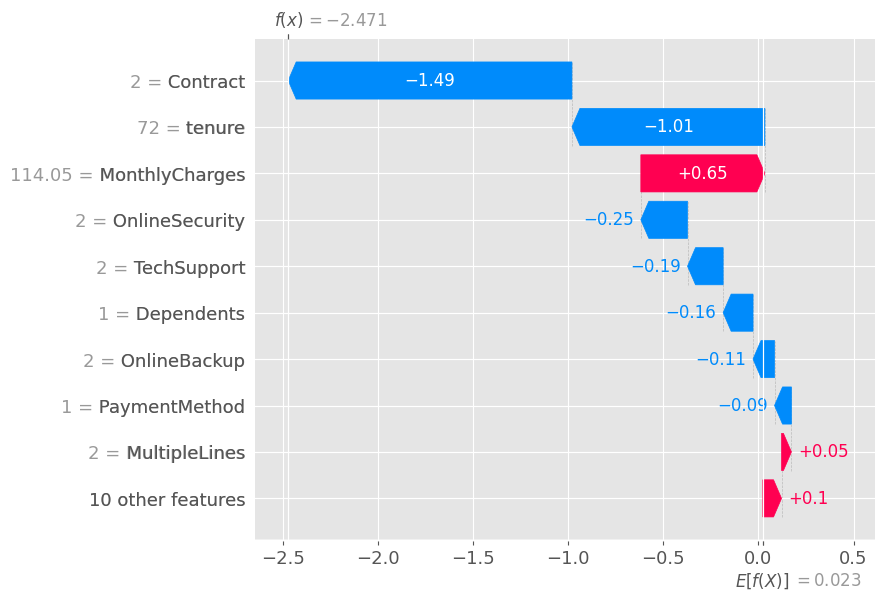

In [34]:
import shap

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])

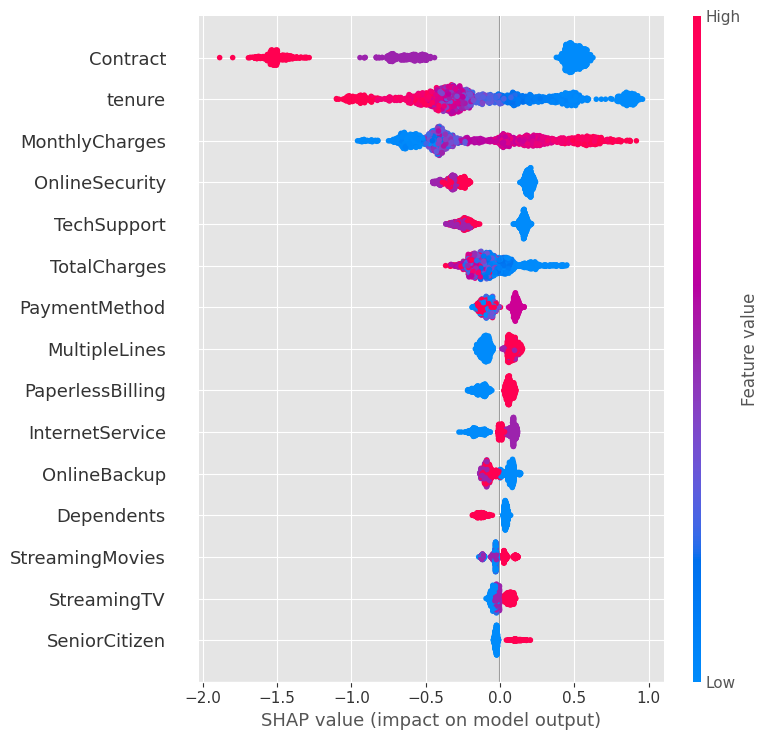

In [35]:
shap.summary_plot(shap_values, X_test, max_display=15)

### observations (shap values):
- Contract affects strongly but asymmetrically (2-year contract strongly pushes to low risk)
- tenure cleanly decreases risk as it increases
- MonthlyCharges does not cleanly predict (does not show up in waterfall plot) but only matters when it interacts with other features. this may suggest 2 different profiles present during this interaction.
- having OnlineSecurity and TechSupport decreases risk directly
- PaperlessBilling and PaymentMethod mildly increase risk 

**note**: MonthlyCharges needs to be investigated



In [ ]:
new_df = original_df.copy()

# binning MonthlyCharges into quintiles to investigate churn rate by contract type and monthly charges segment
# q1: lower monthly charges, q5: higher monthly charges

new_df['MonthlyCharges_quintile'] = pd.qcut(new_df['MonthlyCharges'], q=5, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4', 'Q5 (high)'])
churn_by_segment = new_df.groupby(['Contract', 'MonthlyCharges_quintile'], observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).unstack()

churn_by_segment.round(0)

MonthlyCharges_quintile,Q1 (low),Q2,Q3,Q4,Q5 (high)
Contract,,,,,
Month-to-month,21.0,36.0,45.0,52.0,54.0
One year,3.0,7.0,10.0,12.0,23.0
Two year,1.0,2.0,1.0,3.0,7.0


### observations
- monthlycharges has highest effect on month-to-month users
- monthlycharges has insignificant effect for 2-year contracts

### conclusion
- the longer the contract term, the less effect monthlycharges has
- a long contract term effectively neutralises the positive effect monthlycharges has on risk

## proposed strategy

1. focus on majority (uncommitted cluster) with high churn
2. when focusing on them, it is clear that most have short-term contracts. 
3. to keep these clients, reduce costs for them using promotions
4. OR convert them into long-term contract having clients to neutralise any high charges

**conclusion**: the most effective overall strategy would be to focus on converting month-to-month contract havers to one or two-year contracts as contract term has the largest effect on churn. other strategies like providing more online security and tech support may help marginally, but ultimately focus should still be on converting clients to long-term contracts.